In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, accuracy_score

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

## 1. Data Loading & Stratified Splitting
We load the raw data and split it into training and testing sets. Stratification ensures the class ratio is maintained across both sets.

In [2]:
# Load data
df = pd.read_csv('../data/raw/heart.csv', sep='\t')

# Standardize the target column name to match V2 architecture
if 'target' in df.columns:
    df = df.rename(columns={'target': 'HeartDisease '})

X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']

# Stratified Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 734 samples
Testing set size: 184 samples


## 2. The Unified Preprocessing Pipeline
This is the exact preprocessing logic used in `src/heart_disease/features.py`. It acts as the single source of truth for data transformations.

In [3]:
# Define feature groups
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
categorical_features = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

# Numeric Pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 3. Advanced Stacking Ensemble Architecture

To maximize Sensitivity (Recall) for Class 1 (Disease) while maintaining robust generalization, we upgrade the ensemble to utilize State-of-the-Art (SOTA) tabular models.

**Level-0 (Base Learners) Justification:**
*   **XGBoost & CatBoost:** These gradient boosting frameworks represent the SOTA for tabular data. They efficiently capture complex, non-linear feature interactions. CatBoost utilizes oblivious decision trees, providing structural diversity compared to XGBoost's traditional depth-wise growth.
*   **Support Vector Classifier (SVC):** Utilizing an RBF kernel, the SVC projects data into a high-dimensional space to find margin-based decision boundaries. This provides a fundamentally different mathematical approach compared to tree-based models, ensuring high ensemble diversity—a critical prerequisite for maximizing Recall.

**Level-1 (Meta-Learner) Justification:**
*   **ExtraTreesClassifier vs. MLP/Logistic Regression:** The input space to the meta-learner is extremely low-dimensional (comprising only the 3 probability distributions output by Level-0). In such restricted spaces, Multi-Layer Perceptrons (MLPs) are highly susceptible to severe overfitting, while Logistic Regression rigidly assumes linear separability of the base learners' confidences. 
*   An `ExtraTreesClassifier` (Extremely Randomized Trees) is mathematically superior here. By randomizing the split thresholds, it heavily reduces variance. Furthermore, strictly bounding the tree depth (`max_depth=3`) acts as a strong regularization mechanism, preventing the meta-learner from memorizing Level-0 predictions while still allowing it to capture non-linear combinations of model confidences.

In [8]:
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline

# Define Level-0: Diverse SOTA Base Learners (🌟 Tuned for Maximum Recall)
base_estimators = [
    ('xgb', XGBClassifier(
        eval_metric='logloss', 
        max_depth=3,             # Regularization: Prevent memorization
        reg_lambda=10,           # Regularization: L2 Penalty
        scale_pos_weight=1.5,    # 🌟 Boost Recall for Class 1 (Disease)
        random_state=42
    )),
    ('cat', CatBoostClassifier(
        verbose=0, 
        depth=3,                 # Regularization
        l2_leaf_reg=5,           # Regularization
        auto_class_weights='Balanced', # 🌟 Balance classes for medical priority
        random_state=42
    )),
    ('svc', SVC(
        probability=True, 
        class_weight='balanced', # 🌟 Heavily penalize missing a patient
        random_state=42
    ))
]

# Define Level-1: Heavily Regularized Meta-Learner for Variance Reduction
meta_learner = ExtraTreesClassifier(
    n_estimators=100, 
    max_depth=3, 
    max_features='sqrt', 
    random_state=42
)

# Construct the Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)

# Integrate into the final Pipeline 
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', stacking_clf)
])

print("Tuned SOTA Architecture Loaded Successfully!")

Tuned SOTA Architecture Loaded Successfully!


## 4. Model Training & Standard Evaluation
We train the entire pipeline on the training set and evaluate it on the unseen test set.

In [9]:
from sklearn.metrics import accuracy_score, classification_report

# Train the SOTA Stacking Ensemble
print("Training Advanced Stacking Ensemble Pipeline...")
final_pipeline.fit(X_train, y_train)

# Generate Predictions
y_pred = final_pipeline.predict(X_test)

# Evaluate Performance
print(f"\nFinal Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Training Advanced Stacking Ensemble Pipeline...



Final Accuracy: 0.8967

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.85      0.88        82
           1       0.89      0.93      0.91       102

    accuracy                           0.90       184
   macro avg       0.90      0.89      0.89       184
weighted avg       0.90      0.90      0.90       184



## 5. Advanced Evaluation: Confusion Matrix
Visualizing the confusion matrix helps us understand the False Positives and False Negatives, which are critical in clinical diagnostics.

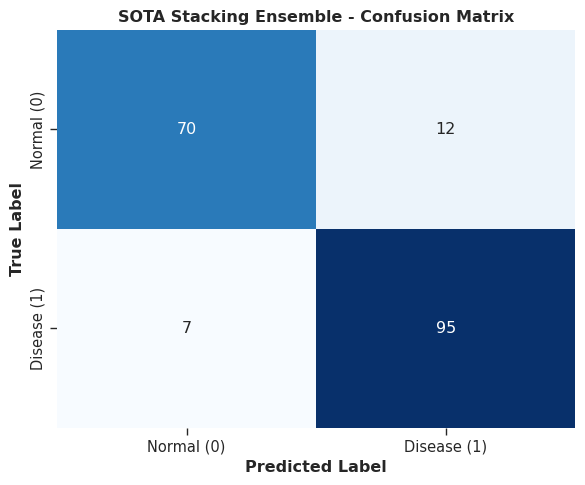

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False, 
    xticklabels=['Normal (0)', 'Disease (1)'], 
    yticklabels=['Normal (0)', 'Disease (1)']
)
plt.title('SOTA Stacking Ensemble - Confusion Matrix', weight='bold')
plt.xlabel('Predicted Label', weight='bold')
plt.ylabel('True Label', weight='bold')
plt.tight_layout()
plt.show()

## 6. Advanced Evaluation: ROC Curve Comparison
To prove the superiority of the Stacking Ensemble, we plot its Receiver Operating Characteristic (ROC) curve against the individual base learners.

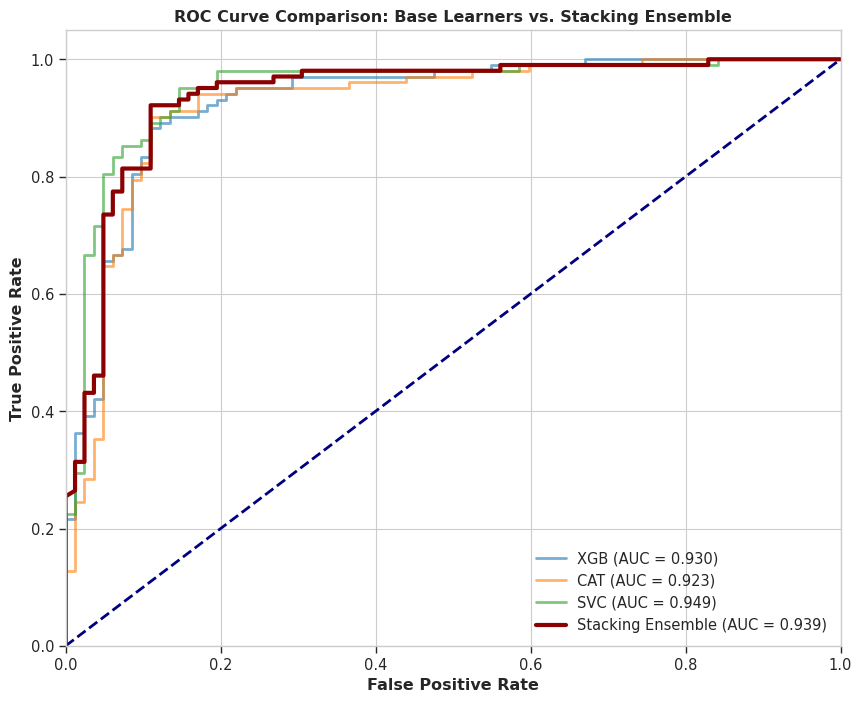

In [11]:
plt.figure(figsize=(10, 8))

# 1. Evaluate Base Learners individually
for name, estimator in base_estimators:
    # Create a temporary pipeline for each base learner
    temp_pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', estimator)])
    temp_pipe.fit(X_train, y_train)
    
    # Get probabilities
    y_proba = temp_pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, alpha=0.6, label=f'{name.upper()} (AUC = {roc_auc:.3f})')

# 2. Evaluate Stacking Ensemble
y_proba_stack = final_pipeline.predict_proba(X_test)[:, 1]
fpr_stack, tpr_stack, _ = roc_curve(y_test, y_proba_stack)
roc_auc_stack = auc(fpr_stack, tpr_stack)

plt.plot(fpr_stack, tpr_stack, color='darkred', lw=3, label=f'Stacking Ensemble (AUC = {roc_auc_stack:.3f})')

# Plot formatting
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', weight='bold')
plt.ylabel('True Positive Rate', weight='bold')
plt.title('ROC Curve Comparison: Base Learners vs. Stacking Ensemble', weight='bold')
plt.legend(loc="lower right")
plt.show()

--- Performance with Clinical Threshold (30.0%) ---
Accuracy: 0.8750

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85        82
           1       0.84      0.96      0.89       102

    accuracy                           0.88       184
   macro avg       0.89      0.86      0.87       184
weighted avg       0.88      0.88      0.87       184



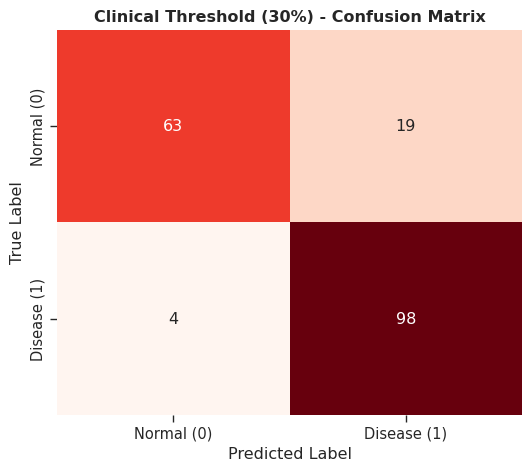

In [12]:
import numpy as np

# 1. سحب "نسبة الشك" بدلاً من القرار النهائي
y_probs = final_pipeline.predict_proba(X_test)[:, 1] # نسبة احتمالية الإصابة بالمرض

# 2. 🌟 العتبة السريرية: أي مريض نسبة شكه 30% فأكثر، نعتبره مريضاً
clinical_threshold = 0.30
y_pred_clinical = (y_probs >= clinical_threshold).astype(int)

# 3. طباعة التقرير بعد فرض العتبة الطبية
print(f"--- Performance with Clinical Threshold ({clinical_threshold*100}%) ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_clinical):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_clinical))

# 4. مصفوفة الالتباس الطبية
plt.figure(figsize=(6, 5))
cm_clinical = confusion_matrix(y_test, y_pred_clinical)
sns.heatmap(
    cm_clinical, annot=True, fmt='d', cmap='Reds', cbar=False, 
    xticklabels=['Normal (0)', 'Disease (1)'], yticklabels=['Normal (0)', 'Disease (1)']
)
plt.title('Clinical Threshold (30%) - Confusion Matrix', weight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()